In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

import requests
from pathlib import Path

from tensorflow.keras.optimizers import Adam

In [ ]:
filepath = "../DATA-HTML-STOCK/NEPSEDATA/adbl.csv"
data = pd.read_csv(filepath)

data = data[['Close']]
data.dropna(inplace=True)

data['Close'] = data['Close'].astype(str).str.replace(',', '').astype(float)

current_price = data.head().iloc[0,0]
print(current_price)

filename = Path(filepath).name.split('.')[0] 
print(filename)
print(data.head())


In [43]:
data = data.iloc[::-1].reset_index(drop=True)

# 70% train, 15% validation, 15% test
train_size = int(0.7 * len(data))
val_size   = int(0.15 * len(data))

train_data = data.iloc[:train_size].values
val_data   = data.iloc[train_size:train_size+val_size].values
test_data  = data.iloc[train_size+val_size:].values

# Scale (fit ONLY on train)
scaler = MinMaxScaler(feature_range=(0, 1))

scaled_train = scaler.fit_transform(train_data)
scaled_val   = scaler.transform(val_data)
scaled_test  = scaler.transform(test_data)

In [44]:
def create_sequences(dataset, time_steps=60):
    X, y = [], []
    for i in range(time_steps, len(dataset)):
        X.append(dataset[i-time_steps:i, 0])
        y.append(dataset[i, 0])
    return np.array(X), np.array(y)

TIME_STEPS = 60

X_train, y_train = create_sequences(scaled_train, TIME_STEPS)
X_val, y_val     = create_sequences(scaled_val, TIME_STEPS)
X_test, y_test   = create_sequences(scaled_test, TIME_STEPS)

# reshape
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_val   = X_val.reshape((X_val.shape[0], X_val.shape[1], 1))
X_test  = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

In [ ]:
dropout=0.2
neuron=64
learningrateofAdam=0.001
batchsize=32
epochIs=100
Patience=15

model = Sequential([
    LSTM(neuron, return_sequences=True, input_shape=(TIME_STEPS, 1)),
    Dropout(dropout),
    LSTM(neuron),
    LSTM(neuron),
    Dropout(dropout),
    Dense(1)
])

optimizer = Adam(learning_rate=learningrateofAdam)

model.compile(
    optimizer=optimizer,
    loss='mean_squared_error'
)

model.summary()


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=Patience,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    epochs=epochIs,
    batch_size=batchsize,
    validation_data=(X_val, y_val),
    callbacks=[early_stop],
    verbose=1
)


In [47]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)


X_train shape: (2403, 60, 1)
X_test shape: (469, 60, 1)


In [48]:
# model.save("lstm_stock_pretrained_model.h5")


In [49]:
# from tensorflow.keras.models import load_model
# model = load_model("lstm_stock_pretrained_model.h5")


In [ ]:
predictions = model.predict(X_test)
predictions_actual = scaler.inverse_transform(predictions).flatten()
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

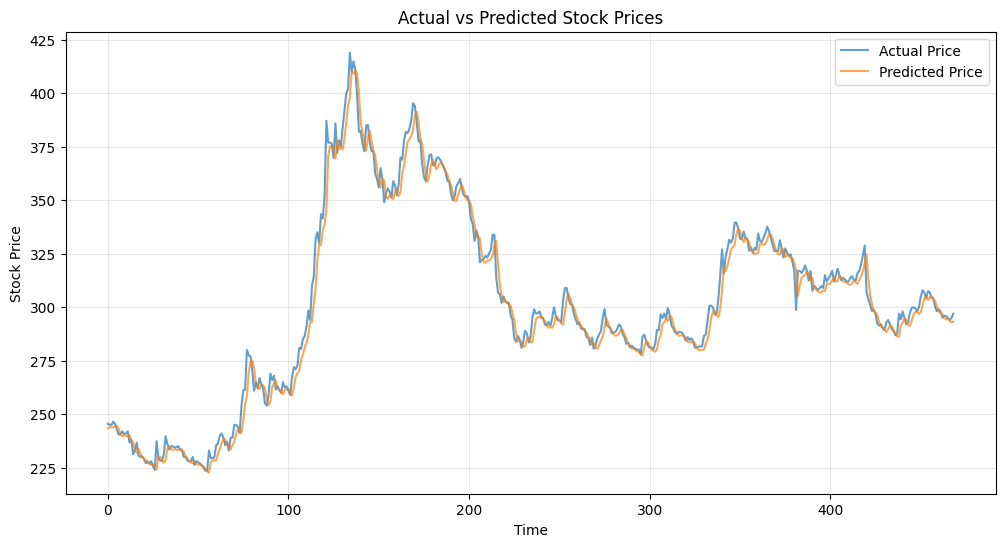

In [51]:
plt.figure(figsize=(12, 6))
plt.plot(y_test_actual, label='Actual Price', alpha=0.7)
plt.plot(predictions_actual, label='Predicted Price', alpha=0.7)
plt.xlabel("Time")
plt.ylabel("Stock Price")
plt.title("Actual vs Predicted Stock Prices")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [60]:
rmse = np.sqrt(mean_squared_error(y_test_actual, predictions_actual))
print(f"\nRMSE: {rmse:.2f}")

from sklearn.metrics import mean_absolute_error
mae = mean_absolute_error(y_test_actual, predictions_actual)
print(f"MAE: {mae:.2f}")

mape = np.mean(np.abs((y_test_actual - predictions_actual) / y_test_actual)) * 100
print(f"MAPE: {mape:.2f}%")


RMSE: 5.92
MAE: 3.97
Directional Accuracy: 51.28%
MAPE: 1.28%


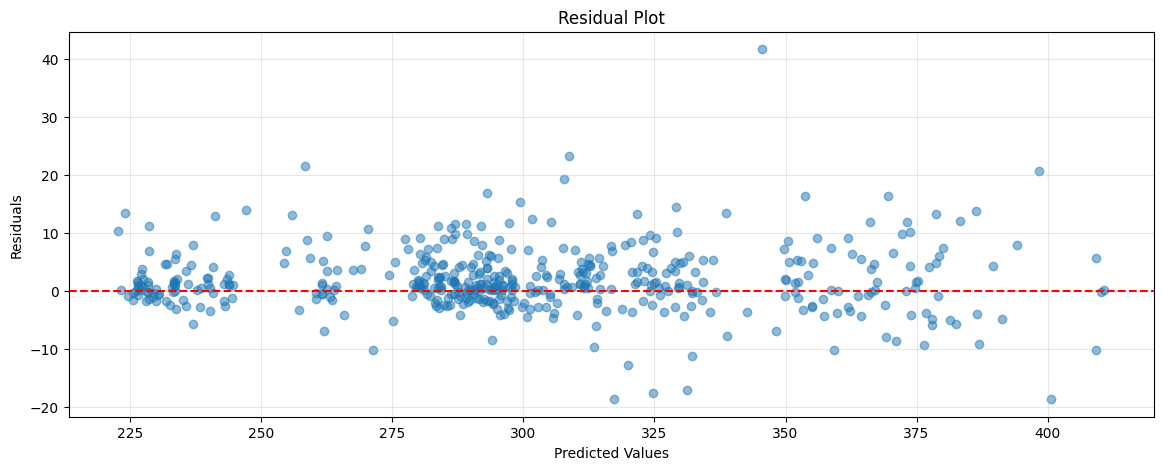

In [56]:
residuals = y_test_actual - predictions_actual
plt.figure(figsize=(14, 5))

plt.subplot(1, 1, 1)
plt.scatter(predictions_actual, residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.grid(True, alpha=0.3)

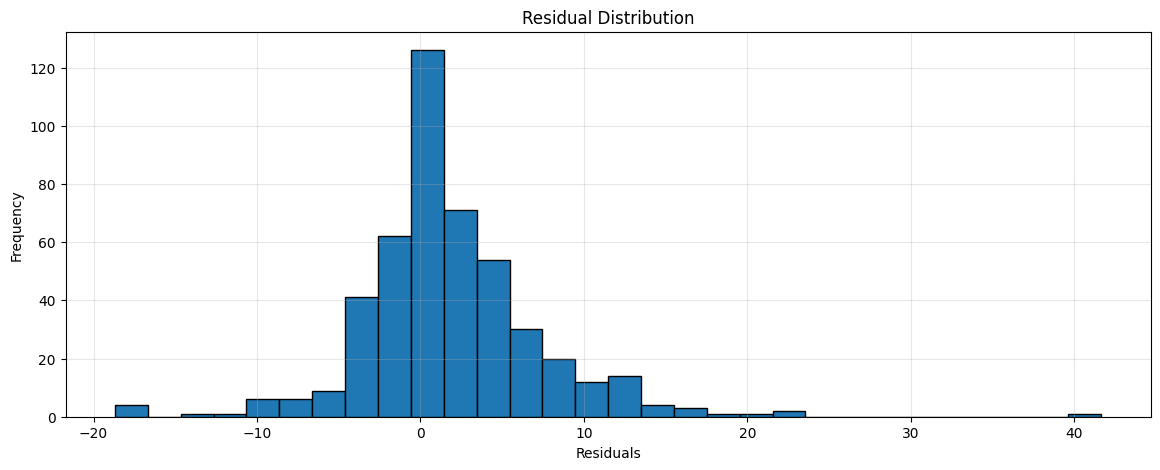

In [57]:
plt.figure(figsize=(14, 5))
plt.subplot(1, 1, 1)
plt.hist(residuals, bins=30, edgecolor='black')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.title('Residual Distribution')
plt.grid(True, alpha=0.3)
plt.show()

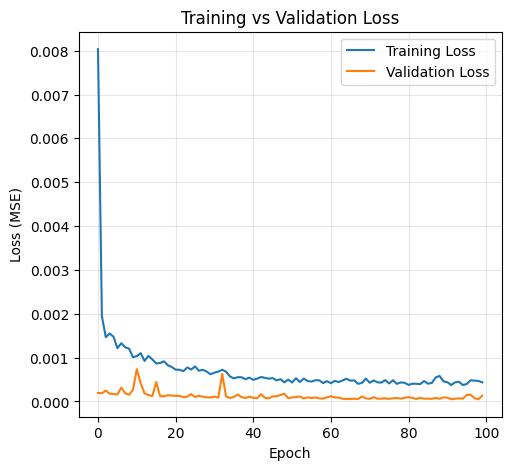

In [58]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True, alpha=0.3)

In [59]:
last_60_days = scaled_test[-60:]

last_60_days = last_60_days.reshape(1, 60, 1)

predicted_scaled = model.predict(last_60_days, verbose=0)
predicted_price = scaler.inverse_transform(predicted_scaled)

print(f"tomorrow predicted price: {predicted_price[0][0]:.2f}")

tomorrow predicted price: 294.42


In [40]:
try:
    responses = requests.post('http://localhost:3000/predicted_price', json={'predicted_price':float(Predicted_price[0][0]), "stock":filename, "current_price":current_price})
    print(f'{responses}')
    print(f'{responses.json()}')
except Exception as e:
    print("Error sending data: ", e)

In [ ]:
# 💡 Summary in 1 sentence each:

# RMSE: Focus on large errors, lower = better.

# MAE: Average error, lower = better.

# MAPE: Percentage error, lower = better.

# R²: How well model explains variation, closer to 1 = better.

# Remove Directional Accuracy unless predicting trend matters.